## Setup Libraru, Pretrained Model, and Dataset

In [1]:
!pip install ultralytics easyocr -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 13.7 MB/s eta 0:00:00


In [2]:
import os
import cv2
import torch
import random
import easyocr
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
!git clone https://github.com/GavinAdriel/Automatic-Number-Plate-Recognition-for-Indonesian-Plates.git

print("\n=== FILE .pt in Repo ===")
!find Automatic-Number-Plate-Recognition-for-Indonesian-Plates -name "*.pt"

Cloning into 'Automatic-Number-Plate-Recognition-for-Indonesian-Plates'...
remote: Enumerating objects: 37, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 37 (delta 13), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (37/37), 4.71 MiB | 10.65 MiB/s, done.
Resolving deltas: 100% (13/13), done.

=== FILE .pt in Repo ===
Automatic-Number-Plate-Recognition-for-Indonesian-Plates/best.pt


In [4]:
model_path = "Automatic-Number-Plate-Recognition-for-Indonesian-Plates/best.pt" 

print(f"[INFO] Loading YOLO model from: {model_path}")
try:
    yolo_model = YOLO(model_path)
    print("[INFO] Custom YOLO model loaded successfully!")
except Exception as e:
    print(f"[ERROR] Failed to load model. Please verify the file path. Details: {e}")

[INFO] Loading YOLO model from: Automatic-Number-Plate-Recognition-for-Indonesian-Plates/best.pt
[INFO] Custom YOLO model loaded successfully!


In [5]:
print("[INFO] Initializing EasyOCR engine...")
reader = easyocr.Reader(['en'], gpu=torch.cuda.is_available())

[INFO] Initializing EasyOCR engine...


In [6]:
images_dir = "/kaggle/input/datasets/linkgish/indonesian-plate-number-from-multi-sources/plate_detection_dataset/plate_detection_dataset/images"
csv_label_path = "/kaggle/input/datasets/linkgish/indonesian-plate-number-from-multi-sources/plate_text_dataset/plate_text_dataset/label.csv"

try:
    df_labels = pd.read_csv(csv_label_path)
    print(f"[INFO] Successfully loaded OCR labels. Total entries: {len(df_labels)}")
except Exception as e:
    print(f"[WARNING] Could not load label.csv. Skipping ground-truth check. Details: {e}")

all_images = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

[INFO] Successfully loaded OCR labels. Total entries: 1863


## Testing Pretrained Models


 Processing random image: train211_jpg.rf.16d1abcb237136ed1bcbcc2ecbc7235d.jpg

image 1/1 /kaggle/input/datasets/linkgish/indonesian-plate-number-from-multi-sources/plate_detection_dataset/plate_detection_dataset/images/train211_jpg.rf.16d1abcb237136ed1bcbcc2ecbc7235d.jpg: 640x640 2 License_Plates, 9.0ms
Speed: 4.7ms preprocess, 9.0ms inference, 29.1ms postprocess per image at shape (1, 3, 640, 640)


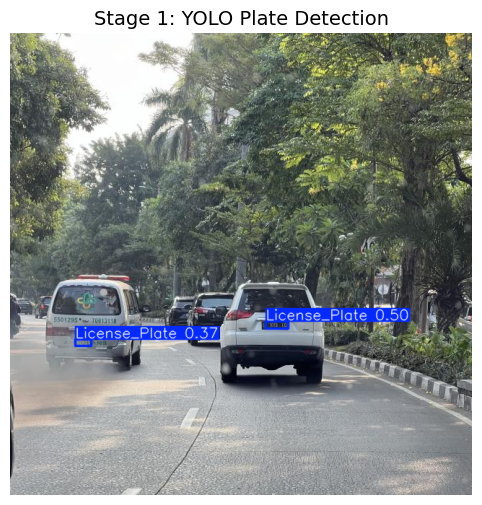


=== STAGE 2: OPTICAL CHARACTER RECOGNITION (OCR) ===


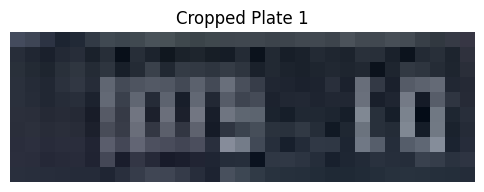

[RESULT] Extracted Text from Plate 1: ''


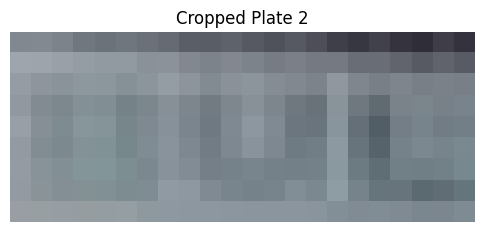

[RESULT] Extracted Text from Plate 2: ''


In [7]:
sample_image_name = random.choice(all_images)
img_path = os.path.join(images_dir, sample_image_name)
print(f"\n Processing random image: {sample_image_name}")


results = yolo_model.predict(source=img_path, conf=0.25)

original_img = cv2.imread(img_path)
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)


res_plotted = results[0].plot()

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Stage 1: YOLO Plate Detection", fontsize=14)
plt.show()

boxes = results[0].boxes.xyxy.cpu().numpy() 

print("\n=== STAGE 2: OPTICAL CHARACTER RECOGNITION (OCR) ===")
if len(boxes) == 0:
    print("[WARNING] YOLO failed to detect any license plates in this image.")
else:
    for i, box in enumerate(boxes):
        xmin, ymin, xmax, ymax = map(int, box[:4])
        
        ymin, ymax = max(0, ymin), min(original_img.shape[0], ymax)
        xmin, xmax = max(0, xmin), min(original_img.shape[1], xmax)
        
        cropped_plate = original_img[ymin:ymax, xmin:xmax]
        
        ocr_result = reader.readtext(cropped_plate, detail=0) 
        
        plt.figure(figsize=(6, 3))
        plt.imshow(cropped_plate)
        plt.axis('off')
        plt.title(f"Cropped Plate {i+1}")
        plt.show()
        
        final_text = " ".join(ocr_result)
        print(f"[RESULT] Extracted Text from Plate {i+1}: '{final_text}'")

## Converting COCO Format to YOLO

In [8]:
import json
import os
from pathlib import Path

annotations_path = "/kaggle/input/datasets/linkgish/indonesian-plate-number-from-multi-sources/plate_detection_dataset/plate_detection_dataset/annotations/annotations.json"
label_image_path = "/kaggle/working/labels"
label_text_path = "/kaggle/input/datasets/linkgish/indonesian-plate-number-from-multi-sources/plate_text_dataset/plate_text_dataset/label.csv"

# Path for image
lp_image_path = "/kaggle/input/datasets/linkgish/indonesian-plate-number-from-multi-sources/plate_detection_dataset/plate_detection_dataset/images"
lp_text_path = "/kaggle/input/datasets/linkgish/indonesian-plate-number-from-multi-sources/plate_text_dataset/plate_text_dataset/dataset"

with open(annotations_path) as f:
    coco = json.load(f)

img_map = {
    img["id"]:{
        **img,
        "width": int(img["width"]),
        "height": int(img["height"])
    }
    for img in coco["images"]
}

os.makedirs("labels", exist_ok=True)

skipped = 0
converted = 0

for ann in coco["annotations"]:
    img_id = ann["image_id"]
    if img_id not in img_map:
        skipped += 1
        continue

    img = img_map[img_id]
    W, H = img["width"], img["height"]

    # COCO bbox: [x_top_left, y_top_left, width, height]
    x, y, w, h = ann["bbox"]

    # Guard against malformed boxes
    if w <= 0 or h <= 0:
        skipped += 1
        continue

    cx = (x + w / 2) / W
    cy = (y + h / 2) / H
    nw = w / W
    nh = h / H

    # Clamp to [0, 1] to handle any out-of-bound annotations
    cx = max(0.0, min(1.0, cx))
    cy = max(0.0, min(1.0, cy))
    nw = max(0.0, min(1.0, nw))
    nh = max(0.0, min(1.0, nh))

    category_id = ann.get("category_id", 0)
    class_idx = category_id  # COCO categories are 1-indexed

    stem = Path(img["file_name"]).stem
    with open(f"labels/{stem}.txt", "a") as f:
        f.write(f"{class_idx} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}\n")

    converted += 1

print(f"Converted: {converted} annotations")
print(f"Skipped:   {skipped} annotations")

Converted: 2128 annotations
Skipped:   0 annotations


## Checking Data

In [9]:
import os

label_files = os.listdir("labels")
print(f"Total label files: {len(label_files)}")  # should be ≤ 546

# Check one file
with open(f"labels/{label_files[0]}") as f:
    print(f.read())

print(f"Total images di JSON : {len(coco['images'])}")
print(f"Total annotations    : {len(coco['annotations'])}")

Total label files: 1372
0 0.279687 0.786719 0.089063 0.019531

Total images di JSON : 1377
Total annotations    : 2128


## Transfer Learning pre-trained YOLOv11

### Split 80/20

In [10]:
import os, shutil, random
from pathlib import Path

random.seed(42)

IMG_SRC = "/kaggle/input/datasets/linkgish/indonesian-plate-number-from-multi-sources/plate_detection_dataset/plate_detection_dataset/images"
LBL_SRC = "/kaggle/working/labels"
BASE    = "/kaggle/working/dataset"

for split in ["train", "val"]:
    os.makedirs(f"{BASE}/images/{split}", exist_ok=True)
    os.makedirs(f"{BASE}/labels/{split}", exist_ok=True)

all_images = [f for f in os.listdir(IMG_SRC) if f.endswith((".png", ".jpg", ".jpeg"))]
random.shuffle(all_images)

split_idx = int(len(all_images) * 0.8)
splits = {"train": all_images[:split_idx], "val": all_images[split_idx:]}

for split, files in splits.items():
    for fname in files:
        stem = Path(fname).stem
        shutil.copy(f"{IMG_SRC}/{fname}", f"{BASE}/images/{split}/{fname}")
        lbl = f"{LBL_SRC}/{stem}.txt"
        if os.path.exists(lbl):
            shutil.copy(lbl, f"{BASE}/labels/{split}/{stem}.txt")

print(f"Train: {len(splits['train'])} | Val: {len(splits['val'])}")

Train: 1106 | Val: 277


### data yaml

In [11]:
yaml_content = f"""
path: {BASE}
train: images/train
val:   images/val
nc: 1
names: ["license_plate"]
"""
with open("/kaggle/working/data.yaml", "w") as f:
    f.write(yaml_content)
print("data.yaml created")

data.yaml created


### Transfer Learning Pretrained YOLO

In [12]:
from ultralytics import YOLO

model = YOLO("Automatic-Number-Plate-Recognition-for-Indonesian-Plates/best.pt")

model.train(
    data="/kaggle/working/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    lr0=0.0001, 
    freeze=10,
    augment=True,
    patience=10,
    project="/kaggle/working/runs",
    name="plate_detect",
    device=0
)


Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=Automatic-Number-Plate-Recognition-for-Indonesian-Plates/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=plate_detect, nbs=64, nms=False, opset=None, optimize=False, optimize

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x780550a48ec0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

## Evaluation GavienAdriel YOLO Model vs Fine-tuned

In [13]:
from ultralytics import YOLO

# ── Model 1: GavinAdriel Original ──
model_original = YOLO("Automatic-Number-Plate-Recognition-for-Indonesian-Plates/best.pt")
metrics_original = model_original.val(
    data="/kaggle/working/data.yaml",
    split="val",
    device=0
)

# ── Model 2: Fine-tuned ──
model_finetuned = YOLO("/kaggle/working/runs/plate_detect/weights/best.pt")
metrics_finetuned = model_finetuned.val(
    data="/kaggle/working/data.yaml",
    split="val",
    device=0
)

# ── Perbandingan ──
print("\n" + "="*50)
print(f"{'Metrik':<15} {'Original':>12} {'Fine-tuned':>12} {'Delta':>10}")
print("="*50)

metrics_list = [
    ("mAP50",     metrics_original.box.map50, metrics_finetuned.box.map50),
    ("mAP50-95",  metrics_original.box.map,   metrics_finetuned.box.map),
    ("Precision", metrics_original.box.mp,    metrics_finetuned.box.mp),
    ("Recall",    metrics_original.box.mr,    metrics_finetuned.box.mr),
]

for name, orig, fine in metrics_list:
    delta = fine - orig
    sign  = "+" if delta >= 0 else ""
    print(f"{name:<15} {orig:>12.4f} {fine:>12.4f} {sign+f'{delta:.4f}':>10}")

print("="*50)


Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2305.9±1680.8 MB/s, size: 238.6 KB)
val: Scanning /kaggle/working/dataset/labels/val.cache... 274 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 277/277 116.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 5.0it/s 3.6s
                   all        277        451      0.567      0.439      0.402     0.0747
Speed: 1.2ms preprocess, 4.7ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1798.2±745.0 MB/s, size: 255.2 KB)
val: Scanning 

## Check Epoch
In here, I checked if i need more epoch for fine-tuning by checking if the training got stopped by early-stopping or the max epoch

In [14]:
import os
result_path = "/kaggle/working/runs/plate_detect/results.csv"

import pandas as pd
df = pd.read_csv(result_path)
print(f"Training stopped at epoch: {len(df)}")
print(df[["epoch", "metrics/mAP50(B)", "metrics/mAP50-95(B)", "val/box_loss"]].tail(10))


Training stopped at epoch: 48
    epoch  metrics/mAP50(B)  metrics/mAP50-95(B)  val/box_loss
38     39           0.75713              0.47895       1.16250
39     40           0.74801              0.46558       1.18606
40     41           0.74961              0.47431       1.17749
41     42           0.75382              0.47789       1.14634
42     43           0.74975              0.47821       1.14656
43     44           0.75578              0.47829       1.14705
44     45           0.75210              0.47305       1.15838
45     46           0.75403              0.47396       1.15624
46     47           0.75877              0.47145       1.14287
47     48           0.75304              0.47737       1.14092


## Overfitting Check

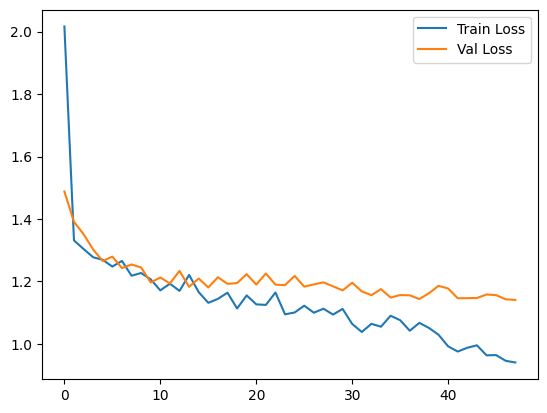

In [15]:
import matplotlib.pyplot as plt

plt.plot(df["train/box_loss"], label="Train Loss")
plt.plot(df["val/box_loss"],   label="Val Loss")
plt.legend()
plt.savefig("/kaggle/working/loss_curve.png")

## My Reasoning
My fine-tuned model is not better, its just overfitting. My training is stagnant at around 45 epochs, maybe the augmentation wasn't aggresive enough and the small weight decay. For the training and augmentation parameters, I might've need to tune it better. 

In [16]:
"""
model = YOLO("Automatic-Number-Plate-Recognition-for-Indonesian-Plates/best.pt")

result = model.tune(
    data="/kaggle/working/data.yaml",
    epochs=10,         
    iterations=20,      
    optimizer="AdamW",
    device=0,
    plots=False,
    save=False,
  
)
"""

'\nmodel = YOLO("Automatic-Number-Plate-Recognition-for-Indonesian-Plates/best.pt")\n\nresult = model.tune(\n    data="/kaggle/working/data.yaml",\n    epochs=10,         \n    iterations=20,      \n    optimizer="AdamW",\n    device=0,\n    plots=False,\n    save=False,\n  \n)\n'

In [17]:
from ultralytics import YOLO

model_final = YOLO("Automatic-Number-Plate-Recognition-for-Indonesian-Plates/best.pt")
model_final.train(
    data="/kaggle/working/data.yaml",
    epochs=80,
    imgsz=640,
    batch=16,
    device=0,
    project="/kaggle/working/runs",
    name="plate_detect_v2",

    # ── Dari hasil model.tune() iteration 17 ──
    lr0=0.00341,
    lrf=0.01867,
    momentum=0.85879,
    weight_decay=0.0005,   
    warmup_epochs=3.09491,
    warmup_momentum=0.85151,
    box=7.00287,
    cls=0.72512,
    dfl=1.7412,
    translate=0.12447,
    scale=0.3768,
    shear=0.00114,
    fliplr=0.46678,
    mosaic=1.0,
    mixup=0.00121,
    copy_paste=0.00471,
    close_mosaic=10,

    hsv_v=0.5,
    hsv_s=0.7,
    hsv_h=0.02353, 
    cos_lr=True,
    patience=15,
    dropout=0.1,
)


Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.00287, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.72512, compile=False, conf=None, copy_paste=0.00471, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.7412, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.46678, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02353, hsv_s=0.7, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.00341, lrf=0.01867, mask_ratio=4, max_det=300, mixup=0.00121, mode=train, model=Automatic-Number-Plate-Recognition-for-Indonesian-Plates/best.pt, momentum=0.85879, mosaic=1.0, multi_scale=0.0, name=plate_detect_v2, nbs=64, nms=False, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7804e87c0440>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

## Final Evaluation

In [18]:
from ultralytics import YOLO
import pandas as pd

model_original  = YOLO("Automatic-Number-Plate-Recognition-for-Indonesian-Plates/best.pt")
model_finetuned = YOLO("/kaggle/working/runs/plate_detect/weights/best.pt")
model_final     = YOLO("/kaggle/working/runs/plate_detect_v2/weights/best.pt")

models = {
    "Original (GavinAdriel)": model_original,
    "Fine-tuned v1":          model_finetuned,
    "Final (tuned+augment)":  model_final,
}

rows = []
for name, model in models.items():
    m = model.val(data="/kaggle/working/data.yaml", split="val", device=0, verbose=False)
    rows.append({
        "Model":     name,
        "mAP50":     round(m.box.map50, 4),
        "mAP50-95":  round(m.box.map, 4),
        "Precision": round(m.box.mp, 4),
        "Recall":    round(m.box.mr, 4),
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))


Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2062.9±1355.1 MB/s, size: 238.6 KB)
val: Scanning /kaggle/working/dataset/labels/val.cache... 274 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 277/277 116.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 5.0it/s 3.6s
                   all        277        451      0.567      0.439      0.402     0.0747
Speed: 1.3ms preprocess, 4.2ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /kaggle/working/runs/detect/val3
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1855.7±1039.9 MB/s, size: 255.2 KB)
val: Scannin

## Export to .onnx

In [19]:
best_model = YOLO("/kaggle/working/runs/plate_detect_v2/weights/best.pt")
best_model.export(format="onnx", imgsz=640, simplify=True)

import shutil
shutil.copy(
    "/kaggle/working/runs/plate_detect_v2/weights/best.onnx",
    "/kaggle/working/final_plate_model.onnx"
)
shutil.copy(
    "/kaggle/working/runs/plate_detect_v2/weights/best.pt",
    "/kaggle/working/final_plate_model.pt"
)
print("")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from '/kaggle/working/runs/plate_detect_v2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (5.2 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 244ms
 Downloaded onnxruntime-gpu
Prepared 2 packages in 2.76s
Installed 2 packages in 12ms
 + onnxruntime-gpu==1.24.2
 + onnxslim==0.1.86

requirements: AutoUpdate success ✅ 3.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 22...


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/utils.py:1447: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  warnings.warn(


ONNX: slimming with onnxslim 0.1.86...
ONNX: export success ✅ 5.3s, saved as '/kaggle/working/runs/plate_detect_v2/weights/best.onnx' (10.1 MB)

Export complete (5.7s)
Results saved to /kaggle/working/runs/plate_detect_v2/weights
Predict:         yolo predict task=detect model=/kaggle/working/runs/plate_detect_v2/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/kaggle/working/runs/plate_detect_v2/weights/best.onnx imgsz=640 data=/kaggle/working/data.yaml  
Visualize:       https://netron.app

